# In what ways do Coding Agents contribute tests? 
#### What types (e.g., unit, integration, end-to-end) are most common?
#### How frequently do Coding Agents contribute tests? How long are the commits by test type and agent?


We weill explore the types of tests coding agents contribute. 

In [105]:
import pandas as pd
import ollama
import pickle
import sys
pr_task_type = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_task_type.parquet")

SKIP_SAMPLES = True
SKIP_LLM = False

In [106]:
SYSTEM_PROMPT = """
You are a highly accurate classifier for software pull requests and commit messages.

Input fields:
- "title": a short PR or commit title
- "reason": an optional explanation of what the PR does

Your task:
Classify the PR into EXACTLY ONE category from this list:

["unit_tests", "integration_tests", "end_to_end_tests", "smoke_tests", "performance_tests", "regression_tests", "none"]

TITLE PRIORITY:
- The TITLE contains the strongest clues.
- If the title clearly references tests, ALWAYS choose a test-related category rather than "none".
- Words that indicate testing activity: "test", "tests", "unit", "coverage", "e2e", "end-to-end", "integration", "cypress", "jest", "pytest", "migrated test", "add tests", "improve tests", "test suite", "test cases".
- If the title starts with "Test", "test:", "tests:", or includes “test”, classify it as testing work unless the reason explicitly contradicts this.

REASON LOGIC:
- Use the reason if it adds helpful detail about the test *type*.
- If the reason is generic, missing, or unclear, rely primarily on the title.
- If the reason mentions fixing a previously known bug, choose "regression_tests".
- If the reason only describes CI, tooling, pre-commit hooks, formatting, or workflows unrelated to tests, choose "none".

CATEGORY DEFINITIONS:

unit_tests
- Tests for individual functions, classes, components, or isolated modules.
- Includes adding missing tests, increasing test coverage, migrating unit test frameworks, or expanding test suites for a single component.

integration_tests
- Tests involving interaction between multiple modules, services, or systems.
- Clues: API + database, service-to-service integration, multi-step internal pipelines.

end_to_end_tests
- Full-system user flows from start to finish.
- Clues: e2e, end-to-end, full workflow, user journey, UI-to-backend, Cypress flows.

smoke_tests
- Minimal/basic tests verifying that the system starts up or that major features work at all.

performance_tests
- Tests for speed, throughput, latency, load, benchmarking, scalability, stress.

regression_tests
- Tests added specifically to prevent a previously known bug, crash, or regression.
- DO NOT choose regression_tests just because the title mentions "error" or "fail".
- Only choose regression_tests if the PR explicitly references:
  - a past bug
  - a crash that occurred before
  - a fix from a previous commit or PR
  - a scenario meant to guard against recurrence

none
- Use ONLY when the PR does not add, modify, or meaningfully change tests.
- Examples:
  - CI config changes
  - pre-commit or workflow updates
  - linting/formatting
  - typo fixes
  - tooling-only updates
- DO NOT choose "none" when the title clearly indicates tests are added or modified.

TIE-BREAKING RULES:
- If title indicates test changes, prefer a test-related category over "none".
- If unsure between unit and integration, choose unit unless multiple systems interact.
- If unsure between integration and end_to_end, choose end_to_end only when the workflow clearly spans a full user-facing or end-to-end path.
- If unsure between unit and regression, choose regression only when previously-known bug or regression is explicitly mentioned.

OUTPUT FORMAT:
- Respond with ONLY the label.
- No punctuation, no quotes, no explanation, no extra words.
"""

In [107]:
# Explore the dataset
print(pr_task_type.shape)
print(pr_task_type.columns)
print(pr_task_type["type"].unique())

# Check for null or missing values
pr_task_type.isna().sum()

# Check for duplicate values
pr_task_type.duplicated().any()


(33596, 6)
Index(['agent', 'id', 'title', 'reason', 'type', 'confidence'], dtype='object')
['fix' 'feat' 'chore' 'docs' 'test' 'refactor' 'build' 'ci' 'perf'
 'revert' 'style' 'other']


False

In [108]:
# Prompt was generated with the help of ChatGPT
PROMPT = SYSTEM_PROMPT

# Function which classifies PR in test into categories
def classify_pr(title: str, reason: str, model="qwen2.5-coder"):
    prompt = f"Title: {title}\nReason: {reason}"
    resp = ollama.chat(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]
    )
    return resp["message"]["content"].strip()

In [109]:
import time

# Number of Samples and Sample Sizes
NUM_SAMPLES = 15
SAMPLE_SIZE = 5

samples = []
pr_test =  pr_task_type[pr_task_type["type"] == "test"]

# Generate samples ad benchmark time taken
def samplePR():
    start_benchmark = time.time()

    for i in range(NUM_SAMPLES):
        start_sample = time.time()

        nth_sample = []
        for index, row in pr_test.sample(n = SAMPLE_SIZE).iterrows():
            title = row.title
            reason = row.reason
            nth_sample.append((title, reason, classify_pr(title, reason)))
        samples.append(nth_sample)

        end_sample = time.time()

        print(f"Time for Sample {i + 1}: {round(end_sample - start_sample, 2)} seconds")

    end_benchmark = time.time()
    print(f"Time: {round(end_benchmark - start_benchmark, 2)} seconds")

In [110]:
if not SKIP_SAMPLES:
    samplePR()

In [111]:
with open("samples.pkl", "wb") as f:
    pickle.dump(samples, f)

In [112]:
with open("samples.pkl", "rb") as f:
    samples = pickle.load(f)
for index, s in enumerate(samples):
    print(f"Sample {index + 1}")
    for n in s:
        print("\t", f"{n[2]:<10} {n[0]}")
        print("\t", f"{' ':<10} {n[1]}")
        print()

We have the following sores for correctly classified tests of each Sample (size 5)

5, 5, 4, 3, 5, 5, 5, 4, 4, 5, 5, 5, 3, 5, 5

We have ~ 90 % accuracy here.

In the next step of the project, we will run the classifier on all ~2300 PRs classified as `test` in the dataset.

In [113]:
def classifyPRLLM():
    results = pd.DataFrame()
    start_benchmark = time.time()
    for index, row in pr_test.iterrows():
        title = row.title
        reason = row.reason
        result = classify_pr(title, reason)
        results = pd.concat([results, pd.DataFrame([row.id, result])], ignore_index=True)
        end_sample = time.time()
        # print(f"Time for Sample {index + 1}: {round(end_sample - start_sample, 2)} seconds")

    end_benchmark = time.time()
    print(f"Time: {round(end_benchmark - start_benchmark, 2)} seconds")
    results.columns = results.columns.astype(str)
    results.to_parquet("results.parquet")

In [114]:
if not SKIP_LLM: 
    classifyPRLLM()

KeyboardInterrupt: 

(2356, 1)


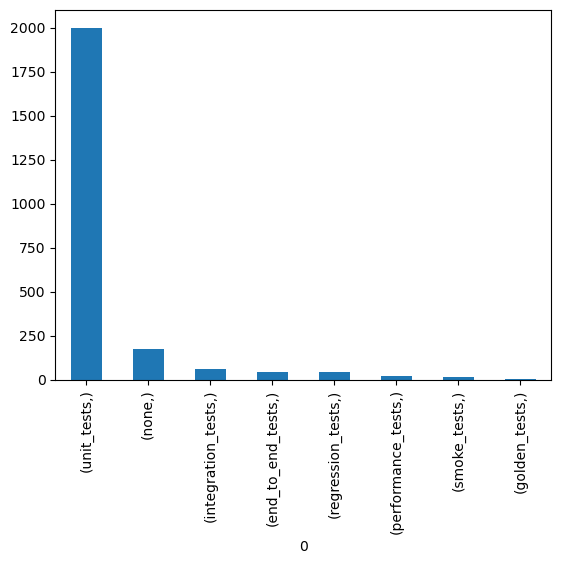

0                
unit_tests           2001
none                  174
integration_tests      58
end_to_end_tests       43
regression_tests       41
performance_tests      21
smoke_tests            17
golden_tests            1
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
results = pd.read_parquet("results.parquet")
print(results.shape)
freq = results.value_counts()
freq.plot(kind='bar')
plt.show()
print(freq)

In [116]:
all_pr_df = pd.read_parquet("hf://datasets/hao-li/AIDev/all_pull_request.parquet")
results = pd.read_parquet("results.parquet")